# QCrank Encoding Python Version for Audio — Shot-Based Measurements

This notebook demonstrates how a short, one-dimensional (single-channel) audio signal with amplitudes in
$[-1,1]$ can be encoded into a quantum state using a uniformly controlled
$R_y$ circuit. It then measures the circuit with a finite number of shots,
decodes the resulting counts, and compares the reconstructed samples with the original signal.

> **Academic Acknowledgement**  
> QCrank was introduced by **Jan Balewski, Mercy G. Amankwah, Roel Van Beeumen,
> E. Wes Bethel, Talita Perciano, and Daan Camps** in *Quantum-parallel vectorized data
> encodings and computations on trapped-ion and transmon QPUs*, *Scientific Reports*
> **14**, 3435 (2024). DOI: [10.1038/s41598-024-53720-x](https://doi.org/10.1038/s41598-024-53720-x).
>
> **Software Acknowledgement**  
> Parts of the Fast Walsh–Hadamard transform, Gray-code circuit decomposition, and
> zero-rotation/CNOT-cancellation logic in this notebook were adapted from the
> [HeidelbergQuantum/QPIXL_ITU-2025](https://github.com/HeidelbergQuantum/QPIXL_ITU-2025)
> repository by Daniel Bultrini and modified for this audio example.

## 1. Introduction: QCrank encoding state and workflow

- For each audio sample $x_j\in[-1,1]$, the notebook defines the logical rotation angle $\phi_j=\frac{\pi}{2}(x_j+1),$ which maps $[-1,1]\mapsto [0,\pi]$

- For $N=2^{n_a}$ samples, the circuit uses:
    - one **data qubit**, $q_0$;
    - $n_a=\log_2N$ **address qubits**.

- The intended encoded state is

$$
|\psi\rangle=
\frac{1}{\sqrt{N}}
\sum_{j=0}^{N-1}
\left[
\cos\left(\frac{\phi_j}{2}\right)|0\rangle+
\sin\left(\frac{\phi_j}{2}\right)|1\rangle
\right]|j\rangle.
$$

- The notebook follows this sequence:

1. Generate a toy audio signal
2. Map its samples to logical $R_y$ angles
3. Transform those angles into uniformly controlled-rotation coefficients
4. Construct the circuit and add measurements
5. Execute the measured circuit with a finite number of shots
6. Recover each angle from data-qubit counts conditioned on its address
7. Map the angles back to audio amplitudes
8. Compare the original and decoded signals

**NOTE:** the logical angles $\phi_j$ are not generally the individual
$R_y$ angles visible in the decomposed circuit. The visible rotations are transformed
coefficients whose signed combinations reproduce the logical angles for each address.
Because decoding now uses finite-shot statistics, the reconstruction is approximate and
changes slightly with the shot count and simulator seed.

## 2. Imports


In [1]:
# Numerical arrays and mathematical operations
import numpy as np

# Plotting the original and reconstructed signals
import matplotlib.pyplot as plt

# Notebook display helpers
from IPython.display import Audio, display

# Qiskit circuit construction and compilation
from qiskit import QuantumCircuit, transpile

# Shot-based QASM simulation
from qiskit_aer import AerSimulator

## 3. Classical preprocessing functions

### 3.1 Binary functions


In [2]:
def is_power_of_two(n): # Checks if the signal length is power of two
    """Return True when ``n`` is a positive integer power of two."""
    # A positive power of two contains exactly one set/activated bit. Clearing its lowest set bit with n & (n - 1) therefore produces zero. 
    # Example: 8 = 1000, 8 - 1 = 7 = 0111, and 8 & 7 = 0. 
    # Bitwise AND (&): 11=1; 10,01,00=0).
    return n > 0 and (n & (n - 1)) == 0


def gray_code(value): # Converts a non-negative integer to its binary-reflected Gray-code representation
    """Return the binary-reflected Gray code of a non-negative integer."""
    # g(i) = i XOR (i shifted right by one bit). Consecutive Gray-code words differ in exactly one bit: 00->01->11->10 = 0->1->3->2. 
    # Example: g(2) = 2 ^ (2 >> 1) = 2 ^ 1 = 3. 
    # Bitwise XOR (^): 11,00=0; 10,01=1.
    return value ^ (value >> 1)


def count_trailing_zeros(value): # Returns the index of the least-significant set/activated bit in a positive integer
    """Return the index of the least-significant set bit in ``value``."""
    if value <= 0:
        raise ValueError("value must be a positive integer")
    # value & -value isolates the least-significant set/activated bit. Its bit length, minus one, gives the zero-based bit position.
    # Example: value = 12 = 1100, -value = -12 = 0100 (two's complement), value & -value = 0100, bit_length() = 3, so index = 2.
    return (value & -value).bit_length() - 1


### 3.2 Scaled Fast Walsh–Hadamard transform and Gray permutation

Let $\boldsymbol{\phi}$ denote the vector of desired logical angles. The decomposition
uses a scaled Walsh–Hadamard transform, followed by a Gray-code permutation, to obtain
the elementary circuit coefficients. With the normalization used below,

$$
\boldsymbol{\alpha}=\frac{1}{N}H_N\boldsymbol{\phi}
$$

before the Gray-code reordering. Compression, when requested, is applied to these
transformed coefficients rather than directly to the audio samples.


In [3]:
def scaled_fwht(values): 
    """
    Apply a scaled Fast Walsh-Hadamard Transform to a copy of ``values``.

    Each butterfly maps (x, y) to ((x + y)/2, (x - y)/2). For an input of
    length N, the repeated factor of 1/2 produces the overall 1/N scaling.
    """
    transformed = np.asarray(values, dtype=float).copy()
    n = transformed.size

    if not is_power_of_two(n):
        raise ValueError("The transform length must be a positive power of two.")

    # ``step`` is the separation between the two entries of each butterfly.
    step = 1
    while step < n:
        # Process independent blocks of length 2 * step.
        for start in range(0, n, 2 * step):
            for offset in range(step):
                left = start + offset
                right = left + step

                # Save both inputs before overwriting either array element.
                x = transformed[left]
                y = transformed[right]

                # Scaled Walsh-Hadamard butterfly.
                transformed[left] = (x + y) / 2.0
                transformed[right] = (x - y) / 2.0

        # Double the butterfly separation for the next transform stage.
        step *= 2

    return transformed


def gray_permutation(values):
    """Return ``values`` reordered by binary-reflected Gray-code indices."""
    values = np.asarray(values)

    # At sequential position i, read the coefficient indexed by gray_code(i).
    return np.array(
        [values[gray_code(i)] for i in range(values.size)],
        dtype=values.dtype,
    )


## 4. Audio-to-angle conversion

The audio samples are linearly mapped from the range $x\in[-1,1]$ to rotation angles $\phi\in[0,\pi]$ using $\phi=\frac{\pi}{2}(x+1), x=\frac{2\phi}{\pi}-1.$

This interval is chosen so that each audio sample corresponds to a unique measurement probability and can therefore be recovered without ambiguity. Negative samples are represented by angles below $\pi/2$, zero corresponds to $\pi/2$, and positive samples are represented by angles above $\pi/2$: $\quad -1\mapsto 0, \quad 0\mapsto\frac{\pi}{2}, \quad 1\mapsto\pi.$



In [4]:
def audio_to_angles(audio):
    """Map finite audio amplitudes in [-1, 1] to RY angles in [0, pi]."""
    audio = np.asarray(audio, dtype=float)

    # Reject invalid floating-point values before constructing the circuit.
    if np.any(~np.isfinite(audio)):
        raise ValueError("The audio signal contains NaN or infinite values.")

    # Do not silently clip or rescale: the caller must supply normalized audio.
    if np.any((audio < -1.0) | (audio > 1.0)):
        raise ValueError("Every audio sample must lie in [-1, 1].")

    return (audio + 1.0) * np.pi / 2.0


def angles_to_audio(angles):
    """Apply the inverse map from RY angles in [0, pi] to [-1, 1]."""
    angles = np.asarray(angles, dtype=float)
    return 2.0 * angles / np.pi - 1.0


## 5. QCrank circuit construction

The address register is first placed in a uniform superposition. A Gray-code sequence of
$R_y$ gates and CNOTs then implements the address-dependent logical rotations.

- Register convention:

    - `q0`: signal/data qubit;
    - `q1, ..., qn`: address qubits;
    - after measuring qubit `qi` into classical bit `ci`, Qiskit displays `c0`
      as the rightmost bit of each counts key.

- Optional compression:

The `compression` argument specifies the percentage of the smallest absolute
transformed coefficients to replace by zero. A zero-angle rotation is the identity, and
adjacent CNOTs can then cancel. Compression therefore reduces gates while retaining the
same number of samples and qubits.

In [5]:
def _control_index(step_index, number_of_address_qubits):
     # Determine which address qubit should control the next CNOT gate. Consecutive Gray-code states differ in exactly one bit, so this function identifies the bit that changes and maps it to the corresponding address qubit.

     # The addresses need to be in Gray code so that the CNOTs can be applied in a single pass through the coefficients. The Gray-code ordering ensures that only one address qubit changes at each step, allowing for efficient circuit construction.

    """Return the address-control index for one Gray-code transition."""
    # There are 2**number_of_address_qubits transformed coefficients.
    final_index = (1 << number_of_address_qubits) - 1

    # Close the cyclic Gray-code path after the final coefficient.
    if step_index == final_index:
        return 0

    # Consecutive Gray words differ in exactly one bit. XOR isolates that bit.
    changed_bit = gray_code(step_index) ^ gray_code(step_index + 1)

    # Reverse the bit position to match the address-qubit ordering used below.
    return (
        number_of_address_qubits
        - count_trailing_zeros(changed_bit)
        - 1
    )


def build_qcrank(audio_signal, compression=0.0):
    """
    Build a compressed, uniformly controlled RY encoding of a 1D audio signal.

    Parameters
    ----------
    audio_signal : array-like
        One-dimensional finite samples in [-1, 1]. The length must be a
        positive power of two.
    compression : float, default=0
        Percentage, from 0 to 100, of the smallest absolute transformed
        coefficients to set to zero.

    Returns
    -------
    QuantumCircuit
        A circuit containing one signal qubit (q0), followed by the address
        qubits (q1, q2, ...).

    Notes
    -----
    The audio-derived ``target_angles`` are the desired logical rotations.
    The individual RY gates placed in the circuit use Walsh-Hadamard-transformed,
    Gray-permuted coefficients; they are not generally equal to the target angles.
    """
    audio_signal = np.asarray(audio_signal, dtype=float)

    # This notebook encodes one scalar sample per address, so the input must be 1D.
    if audio_signal.ndim != 1:
        raise ValueError("audio_signal must be one-dimensional.")

    n = audio_signal.size

    # N = 2**n_address is required for a complete binary address register.
    if not is_power_of_two(n):
        raise ValueError("The signal length must be a positive power of two.")

    if not 0.0 <= compression <= 100.0:
        raise ValueError("compression must lie between 0 and 100.")

    number_of_address_qubits = n.bit_length() - 1

    # Step 1: convert normalized audio samples into desired logical RY angles.
    target_angles = audio_to_angles(audio_signal)

    # Step 2: obtain the elementary rotation coefficients required by the
    # Gray-code uniformly controlled-rotation decomposition.
    coefficients = gray_permutation(scaled_fwht(target_angles))

    # Step 3: optionally remove the smallest coefficients by absolute magnitude.
    # This approximates the target state but can reduce the number of RY/CNOT gates.
    number_to_remove = int((compression / 100.0) * n)
    if number_to_remove:
        smallest = np.argsort(np.abs(coefficients))[:number_to_remove]
        coefficients[smallest] = 0.0

    # One signal qubit plus log2(N) address qubits.
    circuit = QuantumCircuit(
        number_of_address_qubits + 1,
        name="QCrank",
    )

    signal_qubit = 0
    address_qubits = range(1, number_of_address_qubits + 1)

    # Prepare an equal superposition of all N sample addresses.
    circuit.h(address_qubits)

    # Apply the Gray-code sequence of rotations and CNOT transitions.
    i = 0
    while i < n:
        # ``parity`` records the net CNOT controls accumulated while zero
        # rotations are skipped. A control used twice cancels because CX^2 = I.
        parity = 0

        # Avoid adding an identity RY(0) operation.
        if not np.isclose(coefficients[i], 0.0):
            circuit.ry(coefficients[i], signal_qubit)

        # Record the Gray-code transition following this coefficient.
        control = _control_index(i, number_of_address_qubits)
        parity ^= 1 << control
        i += 1

        # Skip consecutive zero rotations while retaining only their net CNOT
        # parity. This is the circuit-compression/cancellation step.
        while i < n and np.isclose(coefficients[i], 0.0):
            control = _control_index(i, number_of_address_qubits)
            parity ^= 1 << control
            i += 1

        # Emit only those CNOTs whose controls occur an odd number of times.
        for bit in range(number_of_address_qubits):
            if (parity >> bit) & 1:
                control_qubit = number_of_address_qubits - bit
                circuit.cx(control_qubit, signal_qubit)

    return circuit


## 6. Shot-based decoder

After all qubits are measured, a counts key has the form
$\texttt{address bits}\,\texttt{signal bit}$ because the signal qubit `q0` is measured
into the rightmost classical bit `c0`. For each address $j$, let $n_{0,j}$ and $n_{1,j}$
be the numbers of shots whose signal-bit outcomes are 0 and 1. The conditional estimates are

$$
\hat p(0\mid j)=\frac{n_{0,j}}{n_{0,j}+n_{1,j}},\qquad
\hat p(1\mid j)=\frac{n_{1,j}}{n_{0,j}+n_{1,j}}.
$$

The reconstructed logical angle and audio sample are

$$
\hat\phi_j=2\operatorname{atan2}\!\left(\sqrt{\hat p(1\mid j)},
\sqrt{\hat p(0\mid j)}\right),\qquad
\hat x_j=\frac{2\hat\phi_j}{\pi}-1.
$$

Conditioning on the address removes the common address probability. An address receiving
no samples cannot be decoded, so the function below raises an error and recommends using
more shots.

In [6]:
def decode_audio_from_counts(counts, number_of_samples):
    """Decode QCrank audio samples from finite-shot measurement counts.

    Parameters
    ----------
    counts : Mapping[str, int]
        Qiskit counts dictionary obtained after measuring every qubit with
        ``q0 -> c0``. The rightmost bit is therefore the signal-qubit outcome.
    number_of_samples : int
        Number of encoded addresses. It must be a positive power of two.

    Returns
    -------
    decoded_audio : numpy.ndarray
        Reconstructed amplitudes in [-1, 1].
    shots_per_address : numpy.ndarray
        Number of measurement outcomes observed for each address.
    probability_one : numpy.ndarray
        Estimated conditional probability of signal outcome 1 at each address.
    """
    if not is_power_of_two(number_of_samples):
        raise ValueError("number_of_samples must be a positive power of two.")

    number_of_address_qubits = number_of_samples.bit_length() - 1
    number_of_qubits = number_of_address_qubits + 1

    counts_zero = np.zeros(number_of_samples, dtype=np.int64)
    counts_one = np.zeros(number_of_samples, dtype=np.int64)

    for raw_bitstring, frequency in counts.items():
        # Remove separators that Qiskit may insert when several classical
        # registers are present, then restore any omitted leading zeros.
        bitstring = raw_bitstring.replace(" ", "").zfill(number_of_qubits)

        if len(bitstring) != number_of_qubits:
            raise ValueError(
                f"Unexpected counts key {raw_bitstring!r} for "
                f"{number_of_qubits} measured qubits."
            )

        # Qiskit prints classical bits from highest to lowest index. Since q0
        # is measured into c0, the rightmost bit is the signal outcome and the
        # remaining prefix is the binary address q_n ... q_1.
        signal_outcome = int(bitstring[-1])
        address_bits = bitstring[:-1]
        address = int(address_bits, 2) if address_bits else 0

        if signal_outcome == 0:
            counts_zero[address] += frequency
        else:
            counts_one[address] += frequency

    shots_per_address = counts_zero + counts_one
    missing_addresses = np.flatnonzero(shots_per_address == 0)
    if missing_addresses.size:
        raise RuntimeError(
            "No shots were observed for address(es) "
            f"{missing_addresses.tolist()}. Increase the number of shots."
        )

    probability_zero = counts_zero / shots_per_address
    probability_one = counts_one / shots_per_address

    # Recover the logical RY angle from conditional measurement probabilities.
    angles = 2.0 * np.arctan2(
        np.sqrt(probability_one),
        np.sqrt(probability_zero),
    )

    decoded_audio = angles_to_audio(angles)
    return decoded_audio, shots_per_address, probability_one

## 7. Generate a toy audio signal

In [7]:
fs = 8000  # Sampling rate in samples per second (Hz)
f = 700    # Sinusoidal frequency in Hz
N = 16     # Number of samples; must be a positive power of two

# Time vector for N samples: t_n = n / fs for n = 0, ..., N - 1.
t = np.arange(N) / fs

# Unit-amplitude sine wave. Its values naturally lie in the required [-1, 1] range.
signal = np.sin(2 * np.pi * f * t)

# Summarize the generated signal segment.
print(f"Number of samples: {len(signal)}")
print(f"Total duration: {len(signal) / fs * 1000:.2f} ms")
print(f"Sampling rate: {fs} Hz")
print(f"Frequency: {f} Hz")

# Play the audio signal
Audio(signal, rate=fs)


Number of samples: 16
Total duration: 2.00 ms
Sampling rate: 8000 Hz
Frequency: 700 Hz


## 8. Encode, measure, simulate, and decode

In [8]:
# Construct the unitary QCrank encoding circuit.
circuit = build_qcrank(signal, compression=0.0)

# Copy the encoding circuit and append one measurement per qubit. ``measure_all``
# maps q0 to c0, so the signal outcome is the rightmost bit in every counts key.
measured_circuit = circuit.copy()
measured_circuit.measure_all()

# Finite-shot simulation settings. Increase ``shots`` for lower statistical noise.
shots = 100
seed_simulator = 12345

simulator = AerSimulator()
compiled_circuit = transpile(measured_circuit, simulator)
result = simulator.run(
    compiled_circuit,
    shots=shots,
    seed_simulator=seed_simulator,
).result()
counts = result.get_counts(compiled_circuit)

# Recover one normalized audio amplitude for every measured address state.
decoded_signal, shots_per_address, probability_one = decode_audio_from_counts(
    counts,
    number_of_samples=signal.size,
)

# Display the numerical comparison and finite-shot diagnostics.
print(f"Total shots: {shots:,}")
print(
    "Shots per address: "
    f"min={shots_per_address.min()}, "
    f"max={shots_per_address.max()}, "
    f"mean={shots_per_address.mean():.1f}"
)

print("\nOriginal signal:")
print(np.round(signal, 6))

print("\nDecoded signal:")
print(np.round(decoded_signal, 6))

absolute_errors = np.abs(decoded_signal - signal)
print("\nMaximum absolute error:")
print(f"{absolute_errors.max():.3e}")

print("\nRoot-mean-square error:")
print(f"{np.sqrt(np.mean(absolute_errors**2)):.3e}")

Total shots: 100
Shots per address: min=2, max=11, mean=6.2

Original signal:
[ 0.        0.522499  0.891007  0.996917  0.809017  0.382683 -0.156434
 -0.649448 -0.951057 -0.97237  -0.707107 -0.233445  0.309017  0.760406
  0.987688  0.92388 ]

Decoded signal:
[-0.539893  1.        1.        1.        1.        1.       -0.057955
 -0.539893 -1.       -1.       -1.       -0.506497  1.        1.
  1.        1.      ]

Maximum absolute error:
6.910e-01

Root-mean-square error:
3.235e-01


## 9. Draw the measured quantum circuit

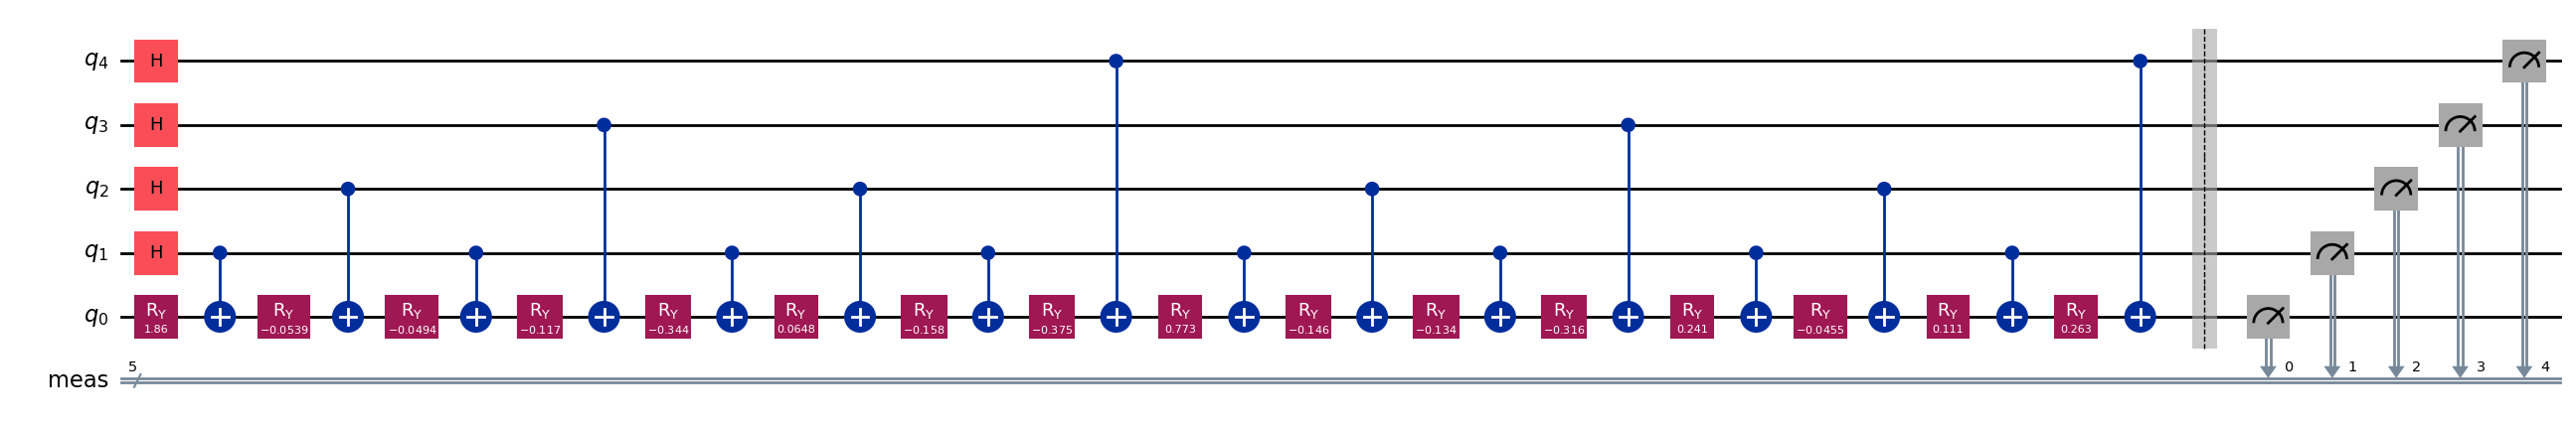

In [9]:
display(
    measured_circuit.draw(
        output="mpl",        # Render as a Matplotlib figure.
        fold=-1,             # Keep the circuit on one horizontal line.
        reverse_bits=True,   # Display q0 at the bottom; computation is unchanged.
    )
)

## 10. Compare the original and decoded signals

With finite shots, the decoded curve should follow the original curve but will not overlap
it exactly. Increasing `shots` generally reduces sampling noise. Raising the compression
percentage can reduce circuit gates but introduces an additional approximation error.

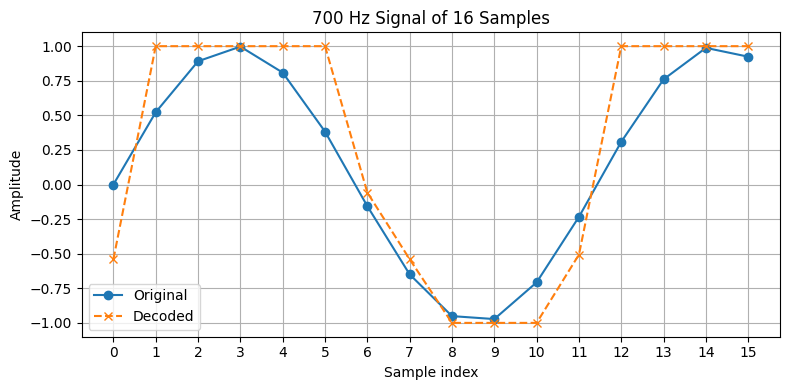

In [10]:
# Use integer sample positions on the horizontal axis.
sample_indices = np.arange(signal.size)

plt.figure(figsize=(8, 4))
plt.plot(sample_indices, signal, "o-", label="Original")
plt.plot(sample_indices, decoded_signal, "x--", label="Decoded")

plt.title(f"{f} Hz Signal of {N} Samples")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.xticks(sample_indices)
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 11. Notes

- **Single data qubit:** this notebook implements one channel on one data
  qubit. The original QCrank proposal can use multiple data qubits.
- **Finite-shot simulation:** decoding uses measured counts from `AerSimulator`,
  not exact statevector probabilities.
- **Statistical uncertainty:** reconstruction error decreases statistically as the
  number of shots increases, although individual runs fluctuate.
- **Address coverage:** each address must occur at least once in the counts. For large
  signals, use enough shots to avoid unobserved addresses.
- **Power-of-two length:** the current implementation requires $N=2^{n_a}$ samples. Other
  lengths would need padding.
- **Compression domain:** compression zeroes small transformed rotation coefficients. It
  does not remove input samples and does not reduce the number of qubits.
- **Probability-based decoding:** the $[0,\pi]$ angle interval is important because a
  measurement-only decoder cannot recover arbitrary amplitude signs or phases.